In [1]:
#import

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn as sk

from sklearn import tree
from sklearn import preprocessing
from sklearn import metrics
from sklearn import model_selection

from PIL import Image
import torch
import torch.nn as nn
import os
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import f1_score

%matplotlib inline
from IPython import display
import gymnasium as gym

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [3]:
import zipfile
with zipfile.ZipFile('./dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('./')

In [4]:
main = pd.read_csv('./data/data_labels_mainData.csv')
extra = pd.read_csv('./data/data_labels_extraData.csv')

In [5]:
IMG_DIR = "./data/images"

In [6]:
main.head()

,InstanceID,patientID,ImageName,cellTypeName,cellType,isCancerous
0,22405,1,22405.png,fibroblast,0,0
1,22406,1,22406.png,fibroblast,0,0
2,22407,1,22407.png,fibroblast,0,0
3,22408,1,22408.png,fibroblast,0,0
4,22409,1,22409.png,fibroblast,0,0


In [7]:
extra.head()

,InstanceID,patientID,ImageName,isCancerous
0,12681,61,12681.png,0
1,12682,61,12682.png,0
2,12683,61,12683.png,0
3,12684,61,12684.png,0
4,12685,61,12685.png,0


In [8]:
print(main.shape)

(9896, 6)


In [9]:
print(extra.shape)

(10384, 4)


In [10]:
#EDA

In [11]:
main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9896 entries, 0 to 9895
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   InstanceID    9896 non-null   int64 
 1   patientID     9896 non-null   int64 
 2   ImageName     9896 non-null   object
 3   cellTypeName  9896 non-null   object
 4   cellType      9896 non-null   int64 
 5   isCancerous   9896 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 464.0+ KB


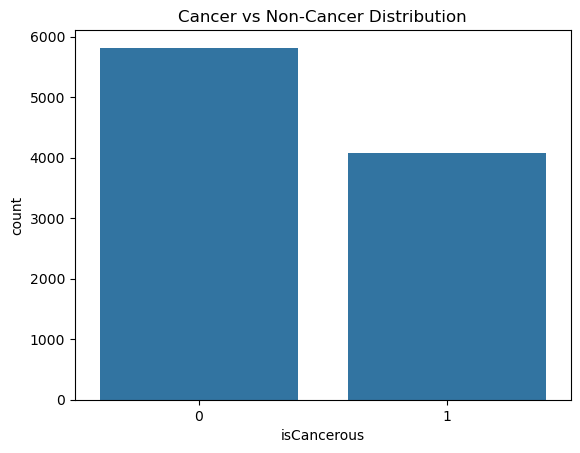

In [12]:
import seaborn as sns

plt.figure()
sns.countplot(data=main, x="isCancerous")
plt.title("Cancer vs Non-Cancer Distribution")
plt.show()

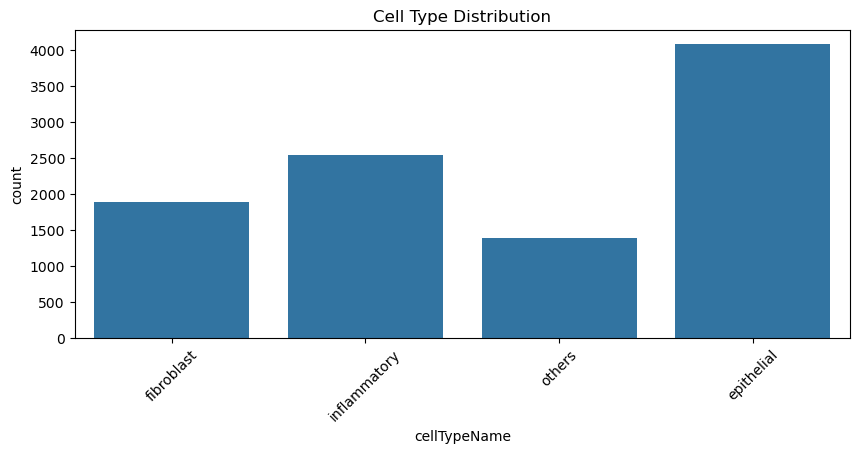

In [13]:
plt.figure(figsize=(10,4))
sns.countplot(data=main, x="cellTypeName")
plt.xticks(rotation=45)
plt.title("Cell Type Distribution")
plt.show()

In [14]:
#data cleaning

In [15]:
#train_data, test_data = train_test_split(main, test_size=0.2, random_state=42)
#train_data, val_data = train_test_split(train_data, test_size=0.25, random_state=42)
#print("Train data : {}, Val Data: {}, Test Data: {}".format(train_data.shape[0], val_data.shape[0], test_data.shape[0]))

In [16]:
#encode

In [17]:
from sklearn.preprocessing import LabelEncoder
main["cellType_encoded"] = LabelEncoder().fit_transform(main["cellType"])

In [18]:
#splitting

In [19]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(main, groups=main["patientID"]))
train_df = main.iloc[train_idx].copy()
test_df = main.iloc[test_idx].copy()

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, val_idx = next(gss_val.split(train_df, groups=train_df["patientID"]))

val_df = train_df.iloc[val_idx].copy()
train_df = train_df.iloc[train_idx].copy()

In [20]:
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 5671
Val: 2386
Test: 1839


In [21]:
###### model Neural Networks ######

In [22]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [23]:
class HistologyDataset(Dataset):
    def __init__(self, df, task="cancer", transform=None):
        self.df = df.reset_index(drop=True)
        self.task = task
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(IMG_DIR, row["ImageName"])
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        if self.task == "cancer":
            label = int(row["isCancerous"])
        else:
            label = int(row["cellType_encoded"])

        return img, label

In [24]:
class CancerNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim[0]*input_dim[1]*input_dim[2], hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim//2, output_classes)
        )

    def forward(self, x):
        return self.net(x)

In [25]:
class CellNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim[0]*input_dim[1]*input_dim[2], hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim//2, output_classes)
        )

    def forward(self, x):
        return self.net(x)

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [27]:
input_dim = (3, 32, 32)
hidden_dim = 256
output_classes = 2

num_classes = main["cellType_encoded"].nunique()
cancer_model = CancerNN(input_dim, hidden_dim, output_classes).to(device)
cell_model = CellNN(input_dim, hidden_dim, num_classes).to(device)

In [28]:
#cancer
train_cancer = HistologyDataset(train_df, "cancer", transform)
val_cancer = HistologyDataset(val_df, "cancer", transform)
test_cancer = HistologyDataset(test_df, "cancer", transform)

train_loader_cancer = DataLoader(train_cancer, 32, shuffle=True)
val_loader_cancer = DataLoader(val_cancer, 32)
test_loader_cancer = DataLoader(test_cancer, 32)

In [29]:
#cell
num_classes = main["cellType_encoded"].nunique()

train_cell = HistologyDataset(train_df, "cell", transform)
val_cell = HistologyDataset(val_df, "cell", transform)
test_cell = HistologyDataset(test_df, "cell", transform)

train_loader_cell = DataLoader(train_cell, 32, shuffle=True)
val_loader_cell = DataLoader(val_cell, 32)
test_loader_cell = DataLoader(test_cell, 32)

In [30]:
#train
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    loss_sum, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        preds = torch.argmax(out, 1)

        correct += (preds == y).sum().item()
        total += y.size(0)

    return loss_sum/len(loader), correct/total

In [31]:
#evkudation
def eval_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            loss_sum += loss.item()
            preds = torch.argmax(out, 1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return loss_sum/len(loader), correct/total

In [32]:
import matplotlib.pyplot as plt
def plot_learning_curve(train_loss, val_loss, train_metric, val_metric, metric_name='Accuracy'):
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.plot(train_loss, 'b--')
    plt.plot(val_loss, 'r--')
    plt.xlabel("epochs")
    plt.ylabel("Loss")
    plt.legend(['train', 'val'], loc='upper left')
    plt.grid()

    plt.subplot(1,2,2)
    plt.plot(train_metric, 'b--')
    plt.plot(val_metric, 'r--')
    plt.xlabel("epochs")
    plt.ylabel(metric_name)
    plt.legend(['train', 'val'], loc='upper left')
    plt.grid()
    
    plt.show()

In [33]:
def test_model(model, loader):
    model.eval()

    preds_all, labels_all = [], []
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            preds = torch.argmax(out, 1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(y.cpu().numpy())

            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total
    f1 = f1_score(labels_all, preds_all, average="macro")

    print("Accuracy:", acc)
    print("F1:", f1)

    return acc, f1

In [34]:
def test_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            loss_sum += loss.item()
            preds = torch.argmax(out, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return loss_sum / len(loader), correct / total

[Epoch 1] Train Loss=0.5369, Train Acc=0.7175 | Val Loss=0.4138, Val Acc=0.8529
[Epoch 2] Train Loss=0.3681, Train Acc=0.8501 | Val Loss=0.3415, Val Acc=0.8663
[Epoch 3] Train Loss=0.3257, Train Acc=0.8609 | Val Loss=0.4475, Val Acc=0.8168
[Epoch 4] Train Loss=0.3150, Train Acc=0.8704 | Val Loss=0.3542, Val Acc=0.8370
[Epoch 5] Train Loss=0.3041, Train Acc=0.8716 | Val Loss=0.3206, Val Acc=0.8722
[Epoch 6] Train Loss=0.3023, Train Acc=0.8709 | Val Loss=0.3274, Val Acc=0.8684
[Epoch 7] Train Loss=0.2953, Train Acc=0.8748 | Val Loss=0.3175, Val Acc=0.8701
[Epoch 8] Train Loss=0.2908, Train Acc=0.8789 | Val Loss=0.3271, Val Acc=0.8546
[Epoch 9] Train Loss=0.2860, Train Acc=0.8836 | Val Loss=0.3320, Val Acc=0.8495
[Epoch 10] Train Loss=0.2804, Train Acc=0.8834 | Val Loss=0.3227, Val Acc=0.8705
[Epoch 11] Train Loss=0.2774, Train Acc=0.8880 | Val Loss=0.3542, Val Acc=0.8541
[Epoch 12] Train Loss=0.2697, Train Acc=0.8864 | Val Loss=0.3187, Val Acc=0.8726
[Epoch 13] Train Loss=0.2680, Train A

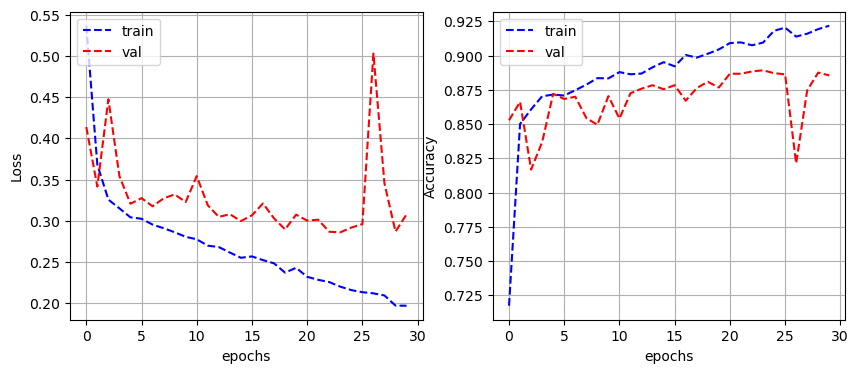

Accuracy: 0.8384991843393148
F1: 0.8375028449787798


(0.8384991843393148, 0.8375028449787798)

In [35]:
input_dim = (3, 32, 32)
hidden_dim = 256
output_classes = 2

cancer_model = CancerNN(
    input_dim,
    hidden_dim,
    output_classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(cancer_model.parameters(), lr=0.01)
#optimizer = torch.optim.Adam(cancer_model.parameters(), lr=1e-3)

history_cancer = {"loss": [], "val_loss": [], "acc": [], "val_acc": []}

epochs = 30

for epoch in range(epochs):
    tr_loss, tr_acc = train_epoch(cancer_model, train_loader_cancer, optimizer, criterion)
    val_loss, val_acc = eval_epoch(cancer_model, val_loader_cancer, criterion)

    history_cancer["loss"].append(tr_loss)
    history_cancer["val_loss"].append(val_loss)
    history_cancer["acc"].append(tr_acc)
    history_cancer["val_acc"].append(val_acc)

    print(f"[Epoch {epoch+1}] "
          f"Train Loss={tr_loss:.4f}, Train Acc={tr_acc:.4f} | "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

plot_learning_curve(
    history_cancer["loss"],
    history_cancer["val_loss"],
    history_cancer["acc"],
    history_cancer["val_acc"]
)

test_model(cancer_model, test_loader_cancer)

[Epoch 1] Train Loss=1.2468, Train Acc=0.4840 | Val Loss=1.1110, Val Acc=0.5637
[Epoch 2] Train Loss=0.9872, Train Acc=0.6232 | Val Loss=1.1429, Val Acc=0.5054
[Epoch 3] Train Loss=0.8591, Train Acc=0.6782 | Val Loss=0.8872, Val Acc=0.6421
[Epoch 4] Train Loss=0.8163, Train Acc=0.6962 | Val Loss=0.9909, Val Acc=0.6010
[Epoch 5] Train Loss=0.7850, Train Acc=0.7101 | Val Loss=0.8895, Val Acc=0.6408
[Epoch 6] Train Loss=0.7767, Train Acc=0.7089 | Val Loss=0.8375, Val Acc=0.6547
[Epoch 7] Train Loss=0.7539, Train Acc=0.7161 | Val Loss=0.9821, Val Acc=0.6014
[Epoch 8] Train Loss=0.7451, Train Acc=0.7159 | Val Loss=0.8285, Val Acc=0.6521
[Epoch 9] Train Loss=0.7375, Train Acc=0.7228 | Val Loss=0.8070, Val Acc=0.6689
[Epoch 10] Train Loss=0.7266, Train Acc=0.7209 | Val Loss=0.8402, Val Acc=0.6584
[Epoch 11] Train Loss=0.7136, Train Acc=0.7258 | Val Loss=0.8333, Val Acc=0.6655
[Epoch 12] Train Loss=0.7101, Train Acc=0.7288 | Val Loss=0.8502, Val Acc=0.6408
[Epoch 13] Train Loss=0.6922, Train A

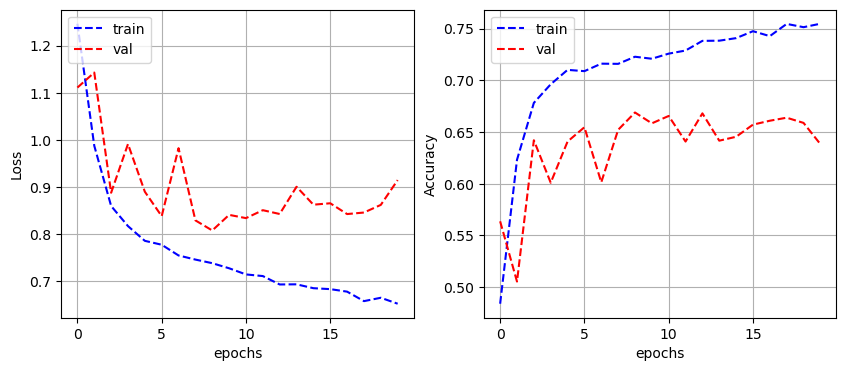

Accuracy: 0.6470908102229472
F1: 0.48848331621429036


(0.6470908102229472, 0.48848331621429036)

In [36]:
num_classes = main["cellType_encoded"].nunique()

cell_model = CellNN(
    input_dim,
    hidden_dim,
    num_classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(cell_model.parameters(), lr=0.01)
#optimizer = torch.optim.Adam(cell_model.parameters(), lr=1e-3)

history_cell = {"loss": [], "val_loss": [], "acc": [], "val_acc": []}

epochs = 20

for epoch in range(epochs):
    tr_loss, tr_acc = train_epoch(cell_model, train_loader_cell, optimizer, criterion)
    val_loss, val_acc = eval_epoch(cell_model, val_loader_cell, criterion)

    history_cell["loss"].append(tr_loss)
    history_cell["val_loss"].append(val_loss)
    history_cell["acc"].append(tr_acc)
    history_cell["val_acc"].append(val_acc)

    print(f"[Epoch {epoch+1}] "
          f"Train Loss={tr_loss:.4f}, Train Acc={tr_acc:.4f} | "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
    
plot_learning_curve(
    history_cell["loss"],
    history_cell["val_loss"],
    history_cell["acc"],
    history_cell["val_acc"]
)

test_model(cell_model, test_loader_cell)

In [37]:
##### deep neural network (week 9) ######

In [38]:
class HistologyDataset(Dataset):
    def __init__(self, dataframe, task="cancer", transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.task = task
        if task == "cell":
            self.classes = sorted(self.dataframe['cellType_encoded'].unique())
            self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        img_path = os.path.join(IMG_DIR, row['ImageName'])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        if self.task == "cancer":
            label = int(row["isCancerous"])
        else:
            label = int(row["cellType_encoded"])

        return image, label

In [39]:
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])


batch_size = 32

In [40]:
train_cancer = HistologyDataset(train_df, task="cancer", transform=train_transform)
val_cancer   = HistologyDataset(val_df, task="cancer", transform=val_transform)

train_cell = HistologyDataset(train_df, task="cell", transform=train_transform)
val_cell   = HistologyDataset(val_df, task="cell", transform=val_transform)


train_loader_cancer = DataLoader(train_cancer, batch_size=batch_size, shuffle=True)
val_loader_cancer   = DataLoader(val_cancer, batch_size=batch_size, shuffle=False)

train_loader_cell = DataLoader(train_cell, batch_size=batch_size, shuffle=True)
val_loader_cell   = DataLoader(val_cell, batch_size=batch_size, shuffle=False)

In [41]:
import matplotlib.pyplot as plt
def plot_learning_curve(train_loss, val_loss, train_metric, val_metric, metric_name='Accuracy'):
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.plot(train_loss, 'b--')
    plt.plot(val_loss, 'r--')
    plt.xlabel("epochs")
    plt.ylabel("Loss")
    plt.legend(['train', 'val'], loc='upper left')
    plt.grid()

    plt.subplot(1,2,2)
    plt.plot(train_metric, 'b--')
    plt.plot(val_metric, 'r--')
    plt.xlabel("epochs")
    plt.ylabel(metric_name)
    plt.legend(['train', 'val'], loc='upper left')
    plt.grid()
    
    plt.show()

In [42]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

class VGGNet(nn.Module):
    def __init__(self, output_classes, dropout=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.Linear(128, output_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

Using device: cpu


In [43]:
def train_model(model, train_loader, val_loader,
                epochs=25, lr=1e-3, weight_decay=0.0):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    history = {
        'loss': [],
        'val_loss': [],
        'accuracy': [],
        'val_accuracy': []
    }

    for epoch in range(epochs):

#train part
        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

        train_loss = total_loss / total
        train_acc = correct / total

#validation part
        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                preds = outputs.argmax(dim=1)

                val_correct += (preds == labels).sum().item()

                val_total += labels.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        history['accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} — "
            f"train_loss: {train_loss:.4f}, "
            f"val_loss: {val_loss:.4f}, "
            f"train_acc: {train_acc:.4f}, "
            f"val_acc: {val_acc:.4f}"
        )

    return history

Epoch 1/20 — train_loss: 0.5600, val_loss: 0.3940, train_acc: 0.7011, val_acc: 0.8173
Epoch 2/20 — train_loss: 0.3885, val_loss: 0.3605, train_acc: 0.8274, val_acc: 0.8709
Epoch 3/20 — train_loss: 0.3230, val_loss: 0.2383, train_acc: 0.8612, val_acc: 0.9132
Epoch 4/20 — train_loss: 0.3157, val_loss: 0.2267, train_acc: 0.8670, val_acc: 0.9170
Epoch 5/20 — train_loss: 0.2865, val_loss: 0.2487, train_acc: 0.8808, val_acc: 0.9103
Epoch 6/20 — train_loss: 0.2779, val_loss: 0.3130, train_acc: 0.8849, val_acc: 0.8873
Epoch 7/20 — train_loss: 0.2640, val_loss: 0.2428, train_acc: 0.8921, val_acc: 0.9053
Epoch 8/20 — train_loss: 0.2739, val_loss: 0.2555, train_acc: 0.8923, val_acc: 0.8944
Epoch 9/20 — train_loss: 0.2732, val_loss: 0.2386, train_acc: 0.8907, val_acc: 0.8998
Epoch 10/20 — train_loss: 0.2620, val_loss: 0.2933, train_acc: 0.9009, val_acc: 0.9019
Epoch 11/20 — train_loss: 0.2470, val_loss: 0.2839, train_acc: 0.9021, val_acc: 0.8994
Epoch 12/20 — train_loss: 0.2432, val_loss: 0.2329, 

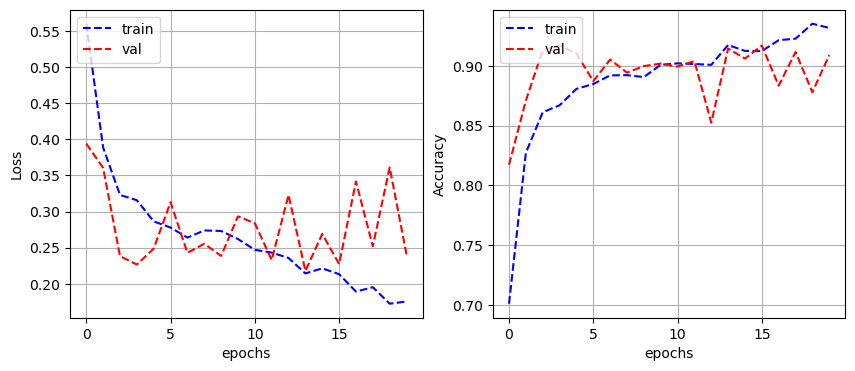

In [44]:
cancer_model = VGGNet(output_classes=2, dropout=0.2)

history_cancer = train_model(
    cancer_model,
    train_loader_cancer,
    val_loader_cancer,
    epochs=20,
    lr=1e-3
)

plot_learning_curve(
    history_cancer['loss'],
    history_cancer['val_loss'],
    history_cancer['accuracy'],
    history_cancer['val_accuracy']
)

Epoch 1/20 — train_loss: 1.2362, val_loss: 1.1214, train_acc: 0.4414, val_acc: 0.4552
Epoch 2/20 — train_loss: 0.9858, val_loss: 0.9728, train_acc: 0.5620, val_acc: 0.5457
Epoch 3/20 — train_loss: 0.9468, val_loss: 0.8662, train_acc: 0.5860, val_acc: 0.6735
Epoch 4/20 — train_loss: 0.8255, val_loss: 0.9503, train_acc: 0.6754, val_acc: 0.6341
Epoch 5/20 — train_loss: 0.7415, val_loss: 0.8143, train_acc: 0.7175, val_acc: 0.6379
Epoch 6/20 — train_loss: 0.7018, val_loss: 0.8092, train_acc: 0.7314, val_acc: 0.6551
Epoch 7/20 — train_loss: 0.6644, val_loss: 1.0658, train_acc: 0.7455, val_acc: 0.5654
Epoch 8/20 — train_loss: 0.6578, val_loss: 0.8686, train_acc: 0.7466, val_acc: 0.6245
Epoch 9/20 — train_loss: 0.6706, val_loss: 0.8353, train_acc: 0.7443, val_acc: 0.6857
Epoch 10/20 — train_loss: 0.6437, val_loss: 0.8843, train_acc: 0.7561, val_acc: 0.6584
Epoch 11/20 — train_loss: 0.5954, val_loss: 0.8954, train_acc: 0.7729, val_acc: 0.6450
Epoch 12/20 — train_loss: 0.5730, val_loss: 0.8814, 

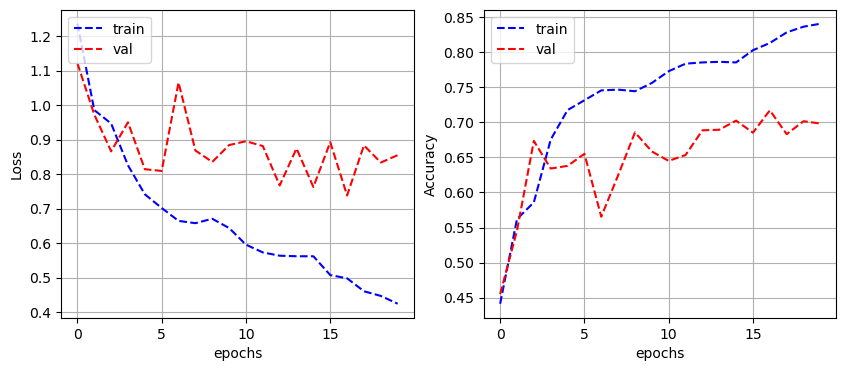

In [45]:
num_classes = main["cellType_encoded"].nunique()

cell_model = VGGNet(output_classes=num_classes, dropout=0.2)

history_cell = train_model(
    cell_model,
    train_loader_cell,
    val_loader_cell,
    epochs=20,
    lr=1e-3
)

plot_learning_curve(
    history_cell['loss'],
    history_cell['val_loss'],
    history_cell['accuracy'],
    history_cell['val_accuracy']
)

In [46]:
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.2, 0.2)
    ),
    transforms.ColorJitter(
        brightness=(0.5, 1.5)
    ),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

In [47]:
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(20),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.15, 0.15),
        scale=(0.9, 1.1)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [48]:
#cancer
train_cancer = HistologyDataset(
    train_df,
    task="cancer",
    transform=train_transform
)

val_cancer = HistologyDataset(
    val_df,
    task="cancer",
    transform=val_transform
)

test_cancer = HistologyDataset(
    test_df,
    task="cancer",
    transform=val_transform
)

In [49]:
#cell
train_cell = HistologyDataset(
    train_df,
    task="cell",
    transform=train_transform
)

val_cell = HistologyDataset(
    val_df,
    task="cell",
    transform=val_transform
)

test_cell = HistologyDataset(
    test_df,
    task="cell",
    transform=val_transform
)

In [50]:
batch_size = 32

train_loader_cancer = DataLoader(
    train_cancer,
    batch_size=batch_size,
    shuffle=True
)

val_loader_cancer = DataLoader(
    val_cancer,
    batch_size=batch_size,
    shuffle=False
)

test_loader_cancer = DataLoader(
    test_cancer,
    batch_size=batch_size,
    shuffle=False
)

In [51]:
train_loader_cell = DataLoader(
    train_cell,
    batch_size=batch_size,
    shuffle=True
)

val_loader_cell = DataLoader(
    val_cell,
    batch_size=batch_size,
    shuffle=False
)

test_loader_cell = DataLoader(
    test_cell,
    batch_size=batch_size,
    shuffle=False
)

In [52]:
reg_lambda = 0.0001

model_VGG_cancer = VGGNet(
    output_classes=2,
    dropout=0.2
)

history_VGG_cancer = train_model(
    model_VGG_cancer,
    train_loader_cancer,
    val_loader_cancer,
    epochs=20,
    lr=1e-3,
    weight_decay=reg_lambda
)

Epoch 1/20 — train_loss: 0.4267, val_loss: 0.6343, train_acc: 0.8014, val_acc: 0.8018
Epoch 2/20 — train_loss: 0.3449, val_loss: 0.2590, train_acc: 0.8522, val_acc: 0.9011
Epoch 3/20 — train_loss: 0.3167, val_loss: 0.3931, train_acc: 0.8663, val_acc: 0.8822
Epoch 4/20 — train_loss: 0.3137, val_loss: 0.2248, train_acc: 0.8683, val_acc: 0.9166
Epoch 5/20 — train_loss: 0.2998, val_loss: 0.2331, train_acc: 0.8722, val_acc: 0.9170
Epoch 6/20 — train_loss: 0.2865, val_loss: 0.3562, train_acc: 0.8836, val_acc: 0.8793
Epoch 7/20 — train_loss: 0.2807, val_loss: 0.2094, train_acc: 0.8827, val_acc: 0.9241
Epoch 8/20 — train_loss: 0.2764, val_loss: 0.2150, train_acc: 0.8875, val_acc: 0.9225
Epoch 9/20 — train_loss: 0.2728, val_loss: 0.2151, train_acc: 0.8868, val_acc: 0.9229
Epoch 10/20 — train_loss: 0.2663, val_loss: 0.2094, train_acc: 0.8910, val_acc: 0.9237
Epoch 11/20 — train_loss: 0.2584, val_loss: 0.2860, train_acc: 0.8949, val_acc: 0.8982
Epoch 12/20 — train_loss: 0.2610, val_loss: 0.2099, 

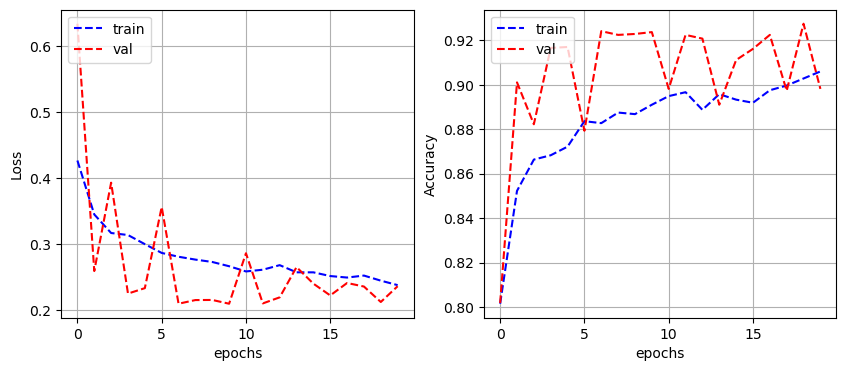

In [53]:
plot_learning_curve(
    history_VGG_cancer['loss'],
    history_VGG_cancer['val_loss'],
    history_VGG_cancer['accuracy'],
    history_VGG_cancer['val_accuracy'],
    metric_name='Accuracy'
)

In [54]:
num_classes = main["cellType_encoded"].nunique()

model_VGG_cell = VGGNet(
    output_classes=num_classes,
    dropout=0.2
)

history_VGG_cell = train_model(
    model_VGG_cell,
    train_loader_cell,
    val_loader_cell,
    epochs=20,
    lr=1e-3,
    weight_decay=reg_lambda
)

Epoch 1/20 — train_loss: 1.0856, val_loss: 1.1615, train_acc: 0.5128, val_acc: 0.3487
Epoch 2/20 — train_loss: 1.0015, val_loss: 0.9403, train_acc: 0.5636, val_acc: 0.5717
Epoch 3/20 — train_loss: 0.9318, val_loss: 0.8304, train_acc: 0.6020, val_acc: 0.6790
Epoch 4/20 — train_loss: 0.8804, val_loss: 0.7413, train_acc: 0.6547, val_acc: 0.7049
Epoch 5/20 — train_loss: 0.7735, val_loss: 0.7496, train_acc: 0.7066, val_acc: 0.7175
Epoch 6/20 — train_loss: 0.7411, val_loss: 0.7488, train_acc: 0.7209, val_acc: 0.7175
Epoch 7/20 — train_loss: 0.7280, val_loss: 0.8202, train_acc: 0.7246, val_acc: 0.6966
Epoch 8/20 — train_loss: 0.7173, val_loss: 0.8925, train_acc: 0.7325, val_acc: 0.6978
Epoch 9/20 — train_loss: 0.7001, val_loss: 0.9689, train_acc: 0.7337, val_acc: 0.6727
Epoch 10/20 — train_loss: 0.6836, val_loss: 0.7687, train_acc: 0.7452, val_acc: 0.7096
Epoch 11/20 — train_loss: 0.6801, val_loss: 0.9376, train_acc: 0.7457, val_acc: 0.6609
Epoch 12/20 — train_loss: 0.6728, val_loss: 0.6726, 

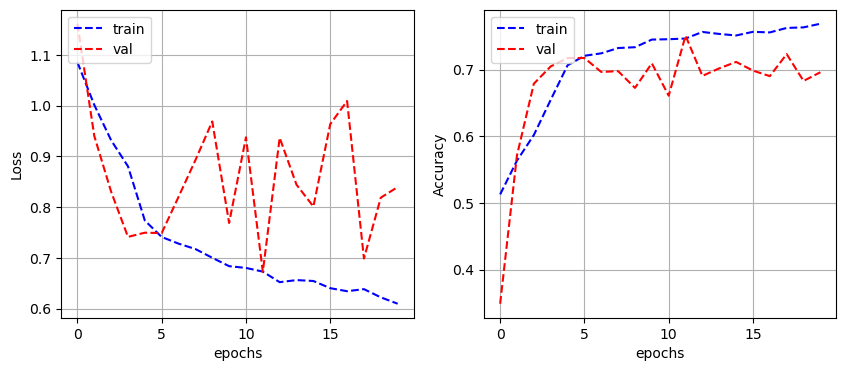

In [55]:
plot_learning_curve(
    history_VGG_cell['loss'],
    history_VGG_cell['val_loss'],
    history_VGG_cell['accuracy'],
    history_VGG_cell['val_accuracy'],
    metric_name='Accuracy'
)

In [56]:
def evaluate_model(model, loader):

    model.eval()

    preds_all = []
    labels_all = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = outputs.argmax(dim=1)

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    macro_f1 = f1_score(
        labels_all,
        preds_all,
        average="macro"
    )

    weighted_f1 = f1_score(
        labels_all,
        preds_all,
        average="weighted"
    )

    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)

In [57]:
evaluate_model(model_VGG_cancer, test_loader_cancer)

Macro F1: 0.8118415695397638
Weighted F1: 0.8116812249910336


In [58]:
evaluate_model(model_VGG_cell, test_loader_cell)

Macro F1: 0.522826329738051
Weighted F1: 0.6453887699171988


In [59]:
torch.save(
    model_VGG_cancer.state_dict(),
    "model_VGG_cancer.pth"
)

In [60]:
torch.save(
    model_VGG_cell.state_dict(),
    "model_VGG_cell.pth"
)

In [61]:
# model 3 class reinfrocemenrt 

In [62]:
#predictions